In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("preprocessed_social_interaction.csv")

In [3]:
dataset

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,14,7.9,7.4,2.9,3.01,1.5,1,2,2,1,0,True,True,False
1,19,1.9,8.0,2.9,3.22,0.8,0,8,1,10,0,False,False,True
2,17,1.3,7.6,0.5,3.92,0.0,0,2,4,2,0,False,True,False
3,15,7.4,6.9,1.6,3.48,0.8,2,1,7,9,0,True,False,True
4,15,4.7,4.9,3.0,2.37,1.4,2,3,5,2,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,6.8,6.6,2.0,2.76,1.0,1,3,4,4,0,False,True,False
1196,16,2.3,8.0,1.9,2.12,0.4,0,7,4,4,0,True,False,False
1197,14,1.7,8.7,0.7,3.98,0.8,0,1,1,1,0,False,False,False
1198,15,3.9,8.5,2.1,3.19,0.6,0,7,9,9,0,True,False,False


In [4]:
highest_academic_row = dataset[dataset['academic_performance'] == dataset['academic_performance'].max()]

In [5]:
highest_academic_row 

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok
122,17,6.0,8.8,1.3,4.0,0.9,2,8,10,7,0,False,False,False
412,13,1.1,7.0,1.9,4.0,0.9,2,2,9,6,0,False,True,False
661,14,6.4,5.6,0.8,4.0,1.9,2,5,1,3,0,True,True,False
979,18,7.7,6.6,1.6,4.0,1.9,0,3,3,9,0,True,False,False
1058,13,1.3,8.7,0.9,4.0,0.1,1,10,9,9,0,False,False,True


In [6]:
lowest_academic_row = dataset[dataset['academic_performance'] == dataset['academic_performance'].min()]

In [7]:
lowest_academic_row

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok
900,16,1.4,5.7,1.8,2.0,1.4,1,4,8,7,0,False,False,False
930,17,4.8,5.6,1.6,2.0,1.3,1,3,8,4,0,True,False,True
1082,14,5.0,6.2,1.0,2.0,1.5,1,5,6,1,0,False,True,False


In [8]:
def quanQual(dataset):
    quan=[]
    qual=[]
    for columnName in dataset.columns:
        #print(columnName)
        if(dataset[columnName].dtype=='O'):
            #print("qual")
            qual.append(columnName)
        else:
            #print("quan")
            quan.append(columnName)
    return quan,qual


In [9]:
quanQual(dataset)

(['age',
  'daily_social_media_hours',
  'sleep_hours',
  'screen_time_before_sleep',
  'academic_performance',
  'physical_activity',
  'social_interaction_level',
  'stress_level',
  'anxiety_level',
  'addiction_level',
  'depression_label',
  'gender_male',
  'platform_usage_Instagram',
  'platform_usage_TikTok'],
 [])

In [10]:
quan,qual=quanQual(dataset)

In [11]:
quan

['age',
 'daily_social_media_hours',
 'sleep_hours',
 'screen_time_before_sleep',
 'academic_performance',
 'physical_activity',
 'social_interaction_level',
 'stress_level',
 'anxiety_level',
 'addiction_level',
 'depression_label',
 'gender_male',
 'platform_usage_Instagram',
 'platform_usage_TikTok']

In [12]:
def Univariate(dataset,quan):
    descriptive=pd.DataFrame(index=["Mean","Median","Mode","Q1:25%","Q2:50%",
                               "Q3:75%","99%","Q4:100%","IQR","1.5rule","Lesser","Greater",
                                    "Min","Max","kurtosis","skew","Var","Std"],columns=quan)
    for columnName in quan:
        descriptive[columnName]["Mean"]=dataset[columnName].mean()
        descriptive[columnName]["Median"]=dataset[columnName].median()
        descriptive[columnName]["Mode"]=dataset[columnName].mode()[0]
        descriptive[columnName]["Q1:25%"]=dataset.describe()[columnName]["25%"]
        descriptive[columnName]["Q2:50%"]=dataset.describe()[columnName]["50%"]
        descriptive[columnName]["Q3:75%"]=dataset.describe()[columnName]["75%"]
        descriptive[columnName]["Q4:100%"]=dataset.describe()[columnName]["max"]
        descriptive[columnName]["IQR"]=descriptive[columnName]["Q3:75%"]-descriptive[columnName]["Q1:25%"]
        descriptive[columnName]["1.5rule"]=1.5*descriptive[columnName]["IQR"]
        descriptive[columnName]["Lesser"]=descriptive[columnName]["Q1:25%"]-descriptive[columnName]["1.5rule"]
        descriptive[columnName]["Greater"]=descriptive[columnName]["Q3:75%"]+descriptive[columnName]["1.5rule"]
        descriptive[columnName]["Min"]=dataset[columnName].min()
        descriptive[columnName]["Max"]=dataset[columnName].max()
        descriptive[columnName]["kurtosis"]=dataset[columnName].kurtosis()
        descriptive[columnName]["skew"]=dataset[columnName].skew()
        descriptive[columnName]["Var"]=dataset[columnName].var()
        descriptive[columnName]["Std"]=dataset[columnName].std()
    return descriptive

In [14]:
quan = dataset.select_dtypes(include=["number"]).columns.tolist()

In [15]:
descriptive_df = Univariate(dataset, quan)

In [16]:
descriptive_df

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
Mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.0145,1.039167,5.445833,5.636667,5.565,0.025833
Median,16.0,4.5,6.5,1.8,2.99,1.0,1.0,5.0,6.0,6.0,0.0
Mode,13,3.5,6.8,1.4,2.36,1.9,2,4,6,6,0
Q1:25%,14.0,2.8,5.2,1.1,2.5,0.5,0.0,3.0,3.0,3.0,0.0
Q2:50%,16.0,4.5,6.5,1.8,2.99,1.0,1.0,5.0,6.0,6.0,0.0
Q3:75%,18.0,6.3,7.6,2.4,3.48,1.5,2.0,8.0,8.0,8.0,0.0
99%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Q4:100%,19.0,8.0,9.0,3.0,4.0,2.0,2.0,10.0,10.0,10.0,1.0
IQR,4.0,3.5,2.4,1.3,0.98,1.0,2.0,5.0,5.0,5.0,0.0
1.5rule,6.0,5.25,3.6,1.95,1.47,1.5,3.0,7.5,7.5,7.5,0.0


In [17]:
dataset.columns

Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'social_interaction_level', 'stress_level', 'anxiety_level',
       'addiction_level', 'depression_label', 'gender_male',
       'platform_usage_Instagram', 'platform_usage_TikTok'],
      dtype='object')

In [18]:
independent=dataset[['age', 'daily_social_media_hours', 'sleep_hours','screen_time_before_sleep', 'academic_performance', 'physical_activity','stress_level', 'anxiety_level','addiction_level', 'depression_label', 'gender_male','platform_usage_Instagram', 'platform_usage_TikTok']]

In [19]:
dependent=dataset[["social_interaction_level"]]

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split 
import time
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import pickle
import matplotlib.pyplot as plt

In [27]:
def selectkbest(indep_X,dep_Y,n):
        test = SelectKBest(score_func=chi2, k=n)
        fit1= test.fit(indep_X,dep_Y)
        selectk_features = fit1.transform(indep_X)
        return selectk_features
    
def split_scalar(indep_X,dep_Y):
        X_train, X_test, y_train, y_test = train_test_split(indep_X, dep_Y, test_size = 0.25, random_state = 0)
        sc = StandardScaler()
        X_train = sc.fit_transform(X_train)
        X_test = sc.transform(X_test)    
        return X_train, X_test, y_train, y_test
    
def cm_prediction(classifier,X_test):
        y_pred = classifier.predict(X_test)
        # Making the Confusion Matrix
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(y_test, y_pred)
        from sklearn.metrics import accuracy_score 
        from sklearn.metrics import classification_report 
        Accuracy=accuracy_score(y_test, y_pred ) 
        report=classification_report(y_test, y_pred)
        return  classifier,Accuracy,report,X_test,y_test,cm

def logistic(X_train,y_train,X_test):       
        # Fitting K-NN to the Training set
        from sklearn.linear_model import LogisticRegression
        classifier = LogisticRegression(random_state = 0)
        classifier.fit(X_train, y_train)
        classifier,Accuracy,report,X_test,y_test,cm=cm_prediction(classifier,X_test)
        return  classifier,Accuracy,report,X_test,y_test,cm      
    
def svm_linear(X_train,y_train,X_test):
                
        from sklearn.svm import SVC
        classifier = SVC(kernel = 'linear', random_state = 0)
        classifier.fit(X_train, y_train)
        classifier,Accuracy,report,X_test,y_test,cm=cm_prediction(classifier,X_test)
        return  classifier,Accuracy,report,X_test,y_test,cm
    
def svm_NL(X_train,y_train,X_test):
                
        from sklearn.svm import SVC
        classifier = SVC(kernel = 'rbf', random_state = 0)
        classifier.fit(X_train, y_train)
        classifier,Accuracy,report,X_test,y_test,cm=cm_prediction(classifier,X_test)
        return  classifier,Accuracy,report,X_test,y_test,cm

def Navie(X_train,y_train,X_test):       
        # Fitting K-NN to the Training set
        from sklearn.naive_bayes import GaussianNB
        classifier = GaussianNB()
        classifier.fit(X_train, y_train)
        classifier,Accuracy,report,X_test,y_test,cm=cm_prediction(classifier,X_test)
        return  classifier,Accuracy,report,X_test,y_test,cm         
    
    
def knn(X_train,y_train,X_test):
           
        # Fitting K-NN to the Training set
        from sklearn.neighbors import KNeighborsClassifier
        classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
        classifier.fit(X_train, y_train)
        classifier,Accuracy,report,X_test,y_test,cm=cm_prediction(classifier,X_test)
        return  classifier,Accuracy,report,X_test,y_test,cm
def Decision(X_train,y_train,X_test):
        
        # Fitting K-NN to the Training set
        from sklearn.tree import DecisionTreeClassifier
        classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
        classifier.fit(X_train, y_train)
        classifier,Accuracy,report,X_test,y_test,cm=cm_prediction(classifier,X_test)
        return  classifier,Accuracy,report,X_test,y_test,cm      


def random(X_train,y_train,X_test):
        
        # Fitting K-NN to the Training set
        from sklearn.ensemble import RandomForestClassifier
        classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
        classifier.fit(X_train, y_train)
        classifier,Accuracy,report,X_test,y_test,cm=cm_prediction(classifier,X_test)
        return  classifier,Accuracy,report,X_test,y_test,cm

In [30]:
def selectk_Classification(acclog,accsvml,accsvmnl,accknn,accnav,accdes,accrf): 
    
    dataframe=pd.DataFrame(index=['ChiSquare'],columns=['Logistic','SVMl','SVMnl','KNN','Navie','Decision','Random'])
    for number,idex in enumerate(dataframe.index):      
        dataframe['Logistic'][idex]=acclog[number]       
        dataframe['SVMl'][idex]=accsvml[number]
        dataframe['SVMnl'][idex]=accsvmnl[number]
        dataframe['KNN'][idex]=accknn[number]
        dataframe['Navie'][idex]=accnav[number]
        dataframe['Decision'][idex]=accdes[number]
        dataframe['Random'][idex]=accrf[number]
    return dataframe
    
dataset1=pd.read_csv("preprocessed_social_interaction.csv",index_col=None)

df2=dataset1

df2 = pd.get_dummies(df2, drop_first=True)

indep_X = df2.drop(columns=["social_interaction_level"])
dep_Y = df2["social_interaction_level"]


In [37]:
kbest=selectkbest(indep_X,dep_Y,1)       

acclog=[]
accsvml=[]
accsvmnl=[]
accknn=[]
accnav=[]
accdes=[]
accrf=[]


X_train, X_test, y_train, y_test=split_scalar(kbest,dep_Y)   
    
        
classifier,Accuracy,report,X_test,y_test,cm=logistic(X_train,y_train,X_test)
acclog.append(Accuracy)

classifier,Accuracy,report,X_test,y_test,cm=svm_linear(X_train,y_train,X_test)  
accsvml.append(Accuracy)
    
classifier,Accuracy,report,X_test,y_test,cm=svm_NL(X_train,y_train,X_test)  
accsvmnl.append(Accuracy)
    
classifier,Accuracy,report,X_test,y_test,cm=knn(X_train,y_train,X_test)  
accknn.append(Accuracy)
    
classifier,Accuracy,report,X_test,y_test,cm=Navie(X_train,y_train,X_test)  
accnav.append(Accuracy)
    
classifier,Accuracy,report,X_test,y_test,cm=Decision(X_train,y_train,X_test)  
accdes.append(Accuracy)
    
classifier,Accuracy,report,X_test,y_test,cm=random(X_train,y_train,X_test)  
accrf.append(Accuracy)
    
result=selectk_Classification(acclog,accsvml,accsvmnl,accknn,accnav,accdes,accrf)

D:\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarn

In [32]:
result #5

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
ChiSquare,0.346667,0.373333,0.353333,0.366667,0.363333,0.32,0.306667


In [34]:
result #4

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
ChiSquare,0.38,0.373333,0.37,0.34,0.386667,0.333333,0.34


In [36]:
result #3

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
ChiSquare,0.383333,0.373333,0.373333,0.34,0.376667,0.4,0.373333


In [38]:
result #1

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
ChiSquare,0.373333,0.373333,0.373333,0.373333,0.373333,0.373333,0.373333


In [39]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    # generate a sample
    sample = dataset
    # calculate parameters
    sample_mean =sample.mean()
    sample_std = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    # define the distribution
    dist = norm(sample_mean, sample_std)
    
    # sample probabilities for a range of outcomes
    values = [value for value in range(startrange, endrange)]
    probabilities = [dist.pdf(value) for value in values]    
    prob=sum(probabilities)
    print("The area between range({},{}):{}".format(startrange,endrange,sum(probabilities)))
    return prob

Mean=1.015, Standard Deviation=0.582
The area between range(1,5):0.8506228711594127


C:\Users\This PC\AppData\Local\Temp\ipykernel_8400\132380739.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


0.8506228711594127

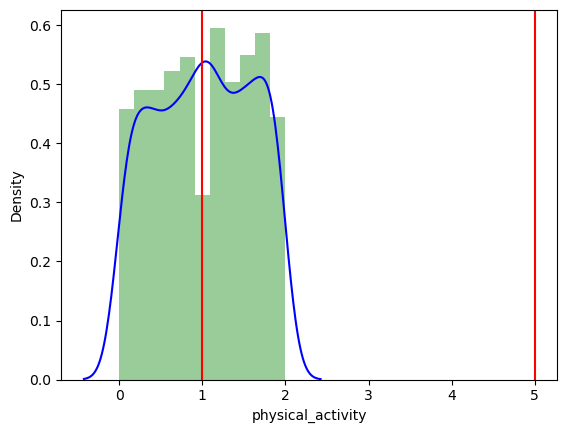

In [41]:
get_pdf_probability(dataset["physical_activity"],1,5)